# Unsupervised Machine Learning: K-Means on California Housing Data

In [ ]:
from matplotlib import pyplot as ply
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kaleido
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#https://www.kaggle.com/datasets/camnugent/california-housing-prices
df=pd.read_csv("C:\\Users\\sew-th\\Documents\\Python Datasets\\california housing.csv")
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


<Axes: >

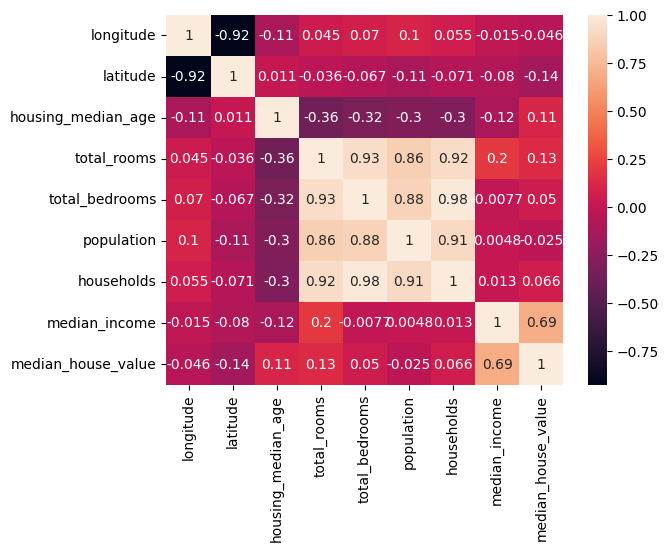

In [3]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
#multicolinearity
#  in 4 variables as evidenced in the heatmap below. Principal component analysis reduces the amount of variables and eliminates multicolinearity.

In [4]:
#dropping categorical columns and empty rows which are only present in total_bedrooms
#scaling
df3=df.drop(['ocean_proximity','total_bedrooms'], axis=1)
scaler=StandardScaler()
scaler.fit(df3)
df4=pd.DataFrame(scaler.transform(df3), columns=df3.columns)

In [5]:
#only fit to check cumsum. 3 principal component seem sufficient (0.82 of variance explained)
pca=PCA(n_components=7)
pca= pca.fit(df4)
pca.explained_variance_ratio_.cumsum()

array([0.37530161, 0.61350859, 0.82497211, 0.93632901, 0.97213816,
       0.9877085 , 0.99466278])

In [6]:
#To see factor loadings by each pc.
#only works with fit, not fit_transform. 
pca_loading=pd.DataFrame(pca.components_, columns=df3.columns )
pca_loading


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,0.124257,-0.126669,-0.269459,0.546841,0.532850,0.544123,0.105214,0.076176
1,-0.663420,0.688167,-0.035248,0.120667,0.099067,0.125228,-0.138352,-0.160811
2,-0.223124,0.100623,0.071316,0.051807,-0.111189,-0.058889,0.672110,0.681731
3,-0.044410,-0.080609,0.917085,0.082835,0.186713,0.199261,-0.213472,0.153255
4,0.103544,0.079539,0.271304,0.131250,0.109880,-0.144997,0.654584,-0.656157
5,-0.199837,-0.143181,-0.071154,-0.598014,0.736656,-0.163645,0.077156,0.038562
6,0.395036,0.406506,0.021261,0.328595,0.322550,-0.627386,-0.170547,0.208649


In [7]:
#doing principal component analysis to reduce variables
pca=PCA(n_components=3)
pca= pca.fit_transform(df4)
pca_data=pd.DataFrame(pca, columns=(['pc1','pc2','pc3']))

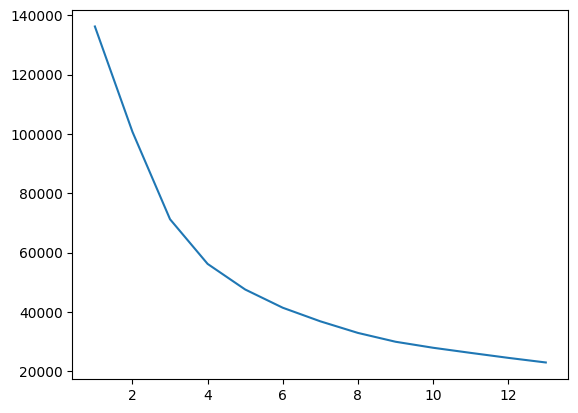

In [8]:
#how many clusters to take with elbow method. It shows the intra cluster spread. Based on the plot 3 cluster seem good enough.
Sum_of_squared_distances = []
K = range(1,14)
for k in K:
    km = KMeans(n_clusters=k, n_init=10).fit(pca_data)
    Sum_of_squared_distances.append(km.inertia_)
plt.plot(K, Sum_of_squared_distances)

In [9]:
#doing kmeans
pca_data['Cluster']=KMeans(n_clusters=3, n_init=10).fit_predict(pca_data)
pca_data['Cluster']=pca_data['Cluster'].astype('category')
#adding to original dataframe
df['Cluster']=pca_data['Cluster'].astype('category')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,Cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,1
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,1


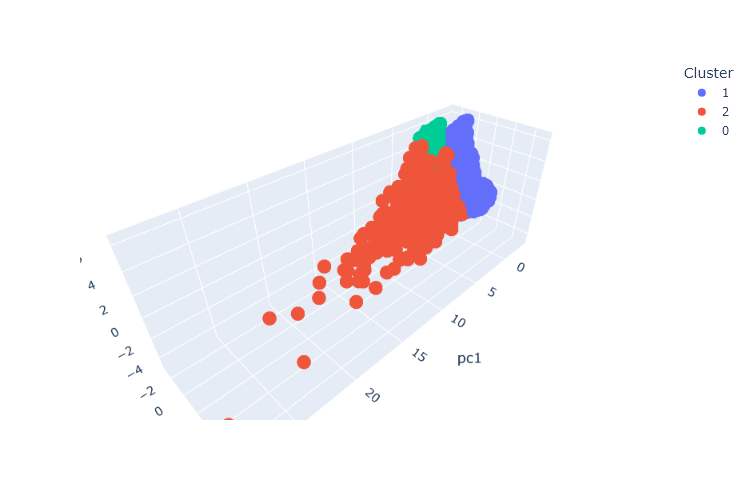

In [18]:
fig = px.scatter_3d(pca_data, 'pc1','pc2','pc3', color='Cluster', width=750,height=500)
fig.show('png')


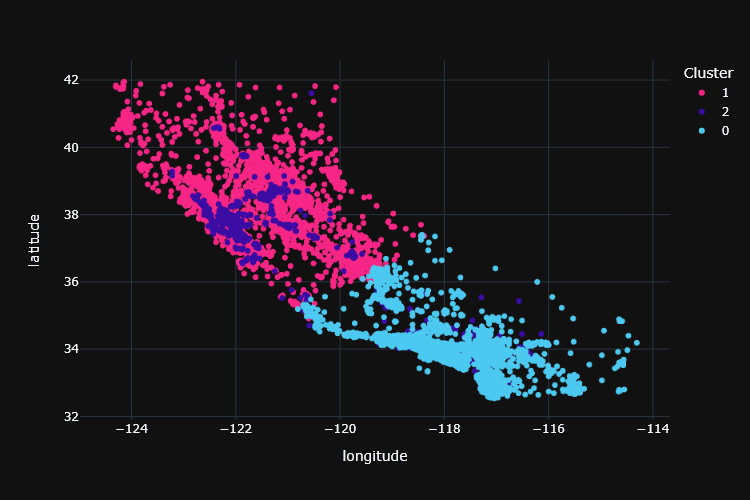

In [10]:
fig = px.scatter(df, 'longitude', 'latitude', color='Cluster', color_discrete_sequence=["#F72585",'#3A0CA3','#4CC9F0'], template='plotly_dark',width=750,height=500 )
fig.show('png')
#cluster 2 stands out.

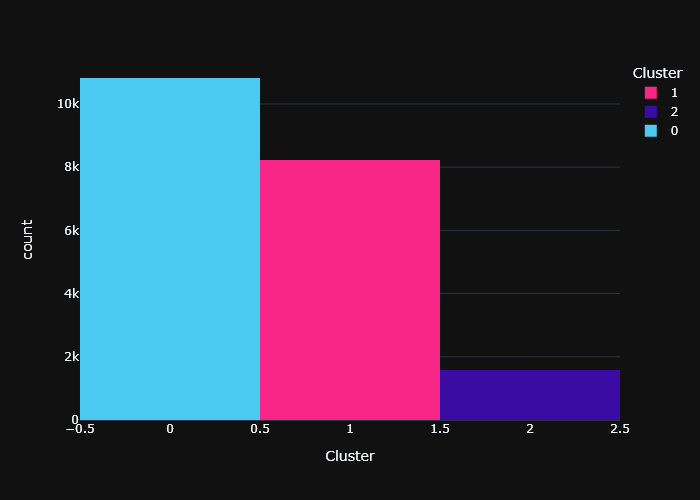

In [11]:
#how many datapoints by cluster are there
fig = px.histogram(df, 'Cluster', color='Cluster', color_discrete_sequence=["#F72585",'#3A0CA3','#4CC9F0'], template='plotly_dark')
fig.show('png')

Analysis

- Cluster 2 households are located mostly around one region. This cluster is the smallest.
- cluster 2 has homes with a lower median_age and more rooms.Even though its the smallest cluster it has the biggest population
- cluster 2 also has a higher average house value and income
- based on the coordinates we can assume cluster 2 corresponds to the people from sillicon valley. 

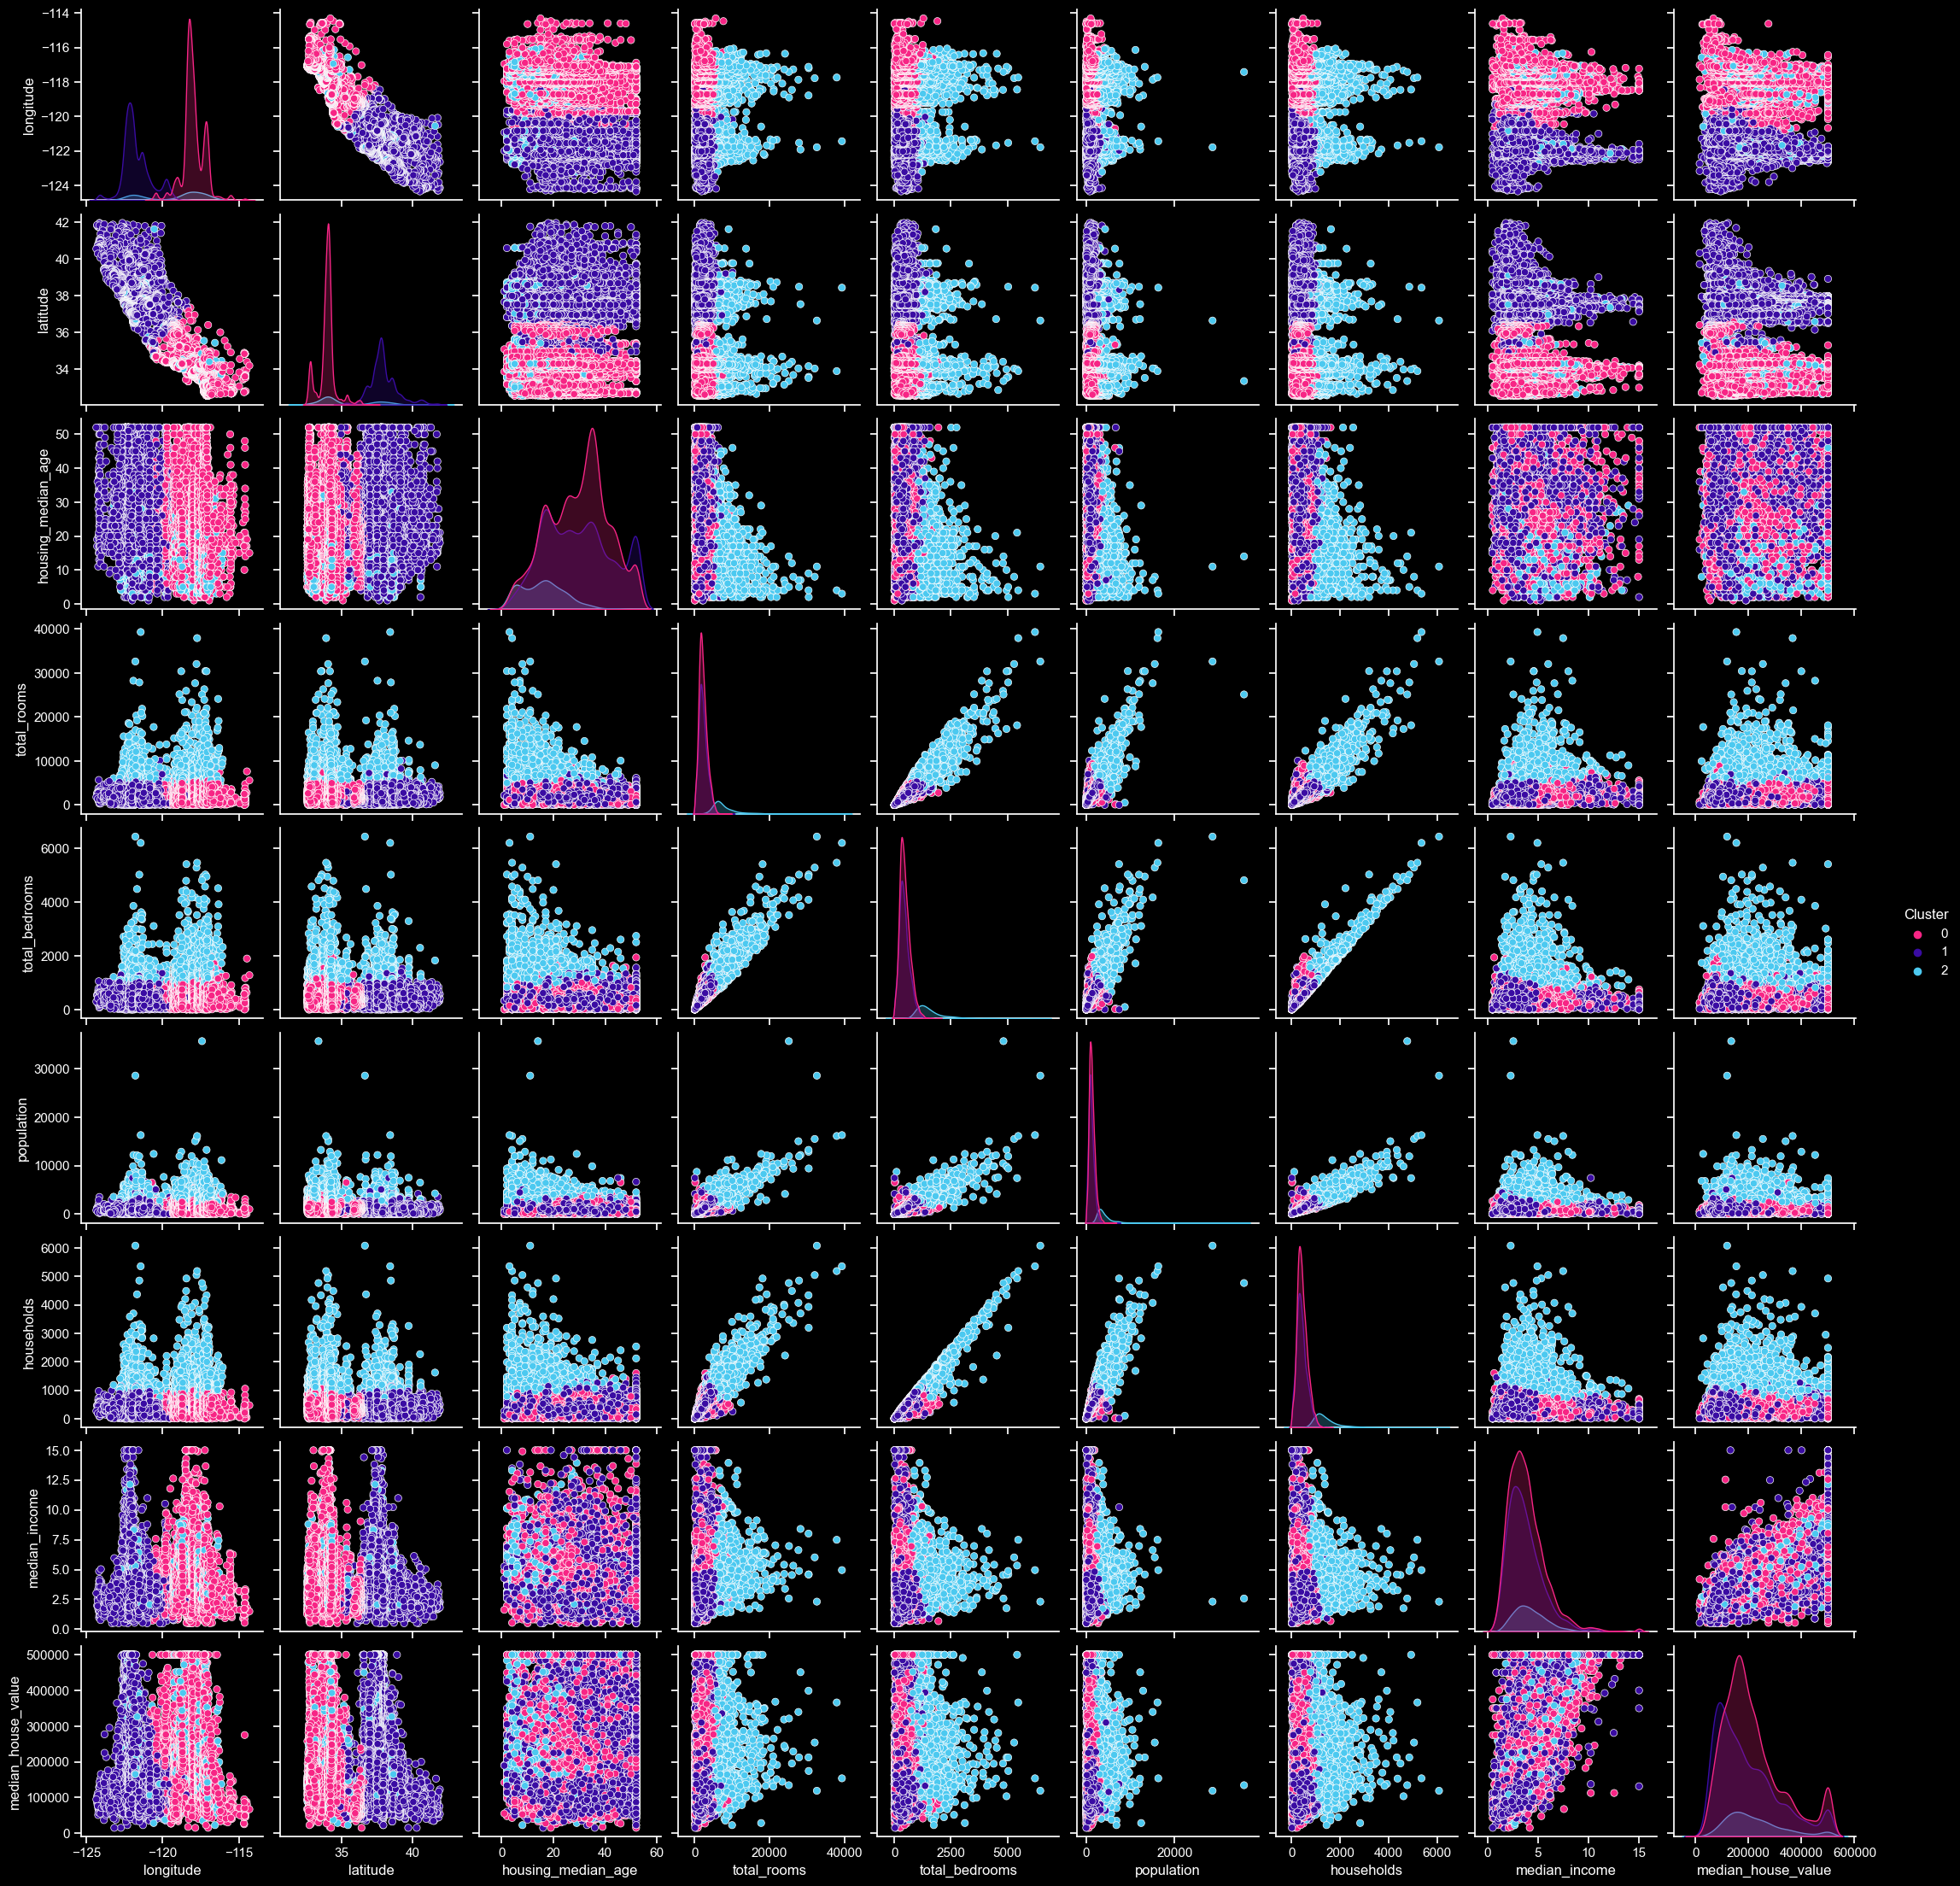

In [ ]:
# Showing the relations of all numeric columns
sns.set(style="ticks")
plt.style.use("dark_background")
sns.pairplot(df, hue='Cluster', palette=["#F72585",'#3A0CA3','#4CC9F0'])

In [15]:
#small table showing the mean values by cluster
df.groupby(by='Cluster').mean( numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
Cluster,,,,,,,,,
0,-118.010208,33.927108,29.641656,2182.860654,460.376202,1272.476529,429.998060,3.893222,213972.358159
1,-121.699361,37.948322,29.771411,2194.845377,439.029834,1111.635766,407.514599,3.747466,194389.858029
2,-119.176145,35.261108,16.030038,7970.965582,1571.893106,4076.003129,1443.861076,4.351710,222785.086358


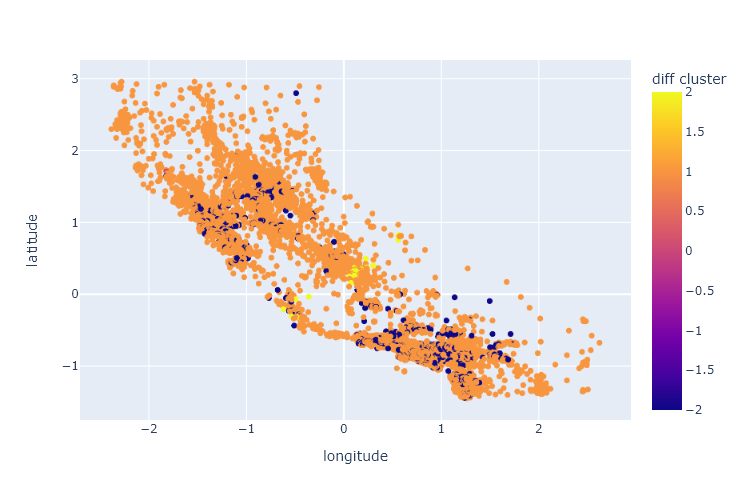

In [16]:
#testing if kmeans without pca is better
df6=df4.copy()
df6['Cluster']=KMeans(n_clusters=3, n_init=10).fit_predict(df6)
df6['Cluster']=df6['Cluster'].astype('category')
df6['PCA cluster']=df['Cluster'].astype('int32')
df6['diff cluster']=df6['Cluster'].astype('int32')-df6['PCA cluster']
fig = px.scatter(df6, 'longitude', 'latitude', color='diff cluster', width=750,height=500 )
fig.show('png')
#same clusters with or without PCA. This means the PCA was succesful - nearly the same clustering while reducing the dataset.

